In [10]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np

import psycopg2
import os
from dotenv import load_dotenv

load_dotenv()

NEON_DATABASE_URL = os.getenv("NEON_DATABASE_URL")

In [11]:
conn = psycopg2.connect(NEON_DATABASE_URL)
cursor = conn.cursor()
query = '''SELECT * FROM ads_appartments'''
cursor.execute(query)
rows = cursor.fetchall()

columns = [description[0] for description in cursor.description]

df = pd.DataFrame(data=rows, columns=columns)

In [12]:
df.head()

,hash_id,title,img_url,link,neighbourhood,type_of_estate,total_price_eur,price_m2_eur,price_m2_bgn,size_m2,...,is_first_floor,is_last_floor,akt16,energy_class,potreblenie,broker_commision,additional_notes,is_furnished,near_public_transport,extras
0,191cff973bff3518de40c8019f6c3d5fea7174c95837aa...,"Имот - продава Двустаен апартамент, в София, М...",https://www.imoti.net/web/files/obiavi/6256545...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Малинова Долина,жилище,128991.00,2263.00,4426.32,57.00,...,False,True,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,False,False,None
1,9eb41908d4e61b7008f29eb1688015f63ff3cdf229084b...,"Имот - продава Двустаен апартамент, в София, М...",https://www.imoti.net/web/files/obiavi/6256546...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Малинова Долина,жилище,128991.00,2263.00,4426.32,57.00,...,False,True,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,False,False,None
2,dbc5d9466f8d880697f9fee292fe7c5fc84663ec10bcd4...,"Имот - продава Двустаен апартамент, в София, В...",https://www.imoti.net/web/files/obiavi/6262276...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Връбница 2,жилище,129000.00,2580.00,5046.04,50.00,...,False,False,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,True,True,Обзаведен; ТЕЦ; Асансьор
3,6833ef4bed6c98041e1c7433fc60698103a43595c45950...,"Имот - продава Двустаен апартамент, в София, В...",https://www.imoti.net/web/files/obiavi/6246165...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Връбница 2,жилище,128984.00,2804.00,5484.83,46.00,...,False,False,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,True,True,Обзаведен
4,65707b6e4a05c4b88ad12e0779c1fc35bd125f66133bc6...,"Имот - продава Едностаен апартамент, в София, ...",https://www.imoti.net/web/files/obiavi/6248616...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Малинова Долина,жилище,133014.00,3167.00,6193.46,42.00,...,False,False,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,False,True,None


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4848 entries, 0 to 4847
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   hash_id                4848 non-null   object 
 1   title                  4848 non-null   object 
 2   img_url                4845 non-null   object 
 3   link                   4848 non-null   object 
 4   neighbourhood          4745 non-null   object 
 5   type_of_estate         4848 non-null   object 
 6   total_price_eur        4815 non-null   float64
 7   price_m2_eur           4815 non-null   float64
 8   price_m2_bgn           4821 non-null   float64
 9   size_m2                4815 non-null   float64
 10  nr_of_rooms            4735 non-null   float64
 11  description            4848 non-null   object 
 12  floor                  4762 non-null   float64
 13  is_first_floor         4762 non-null   object 
 14  is_last_floor          3574 non-null   object 
 15  akt1

In [16]:
numeric_cols = ['total_price_eur', 'price_m2_eur', 'price_m2_bgn', 'size_m2']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4848 entries, 0 to 4847
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   hash_id                4848 non-null   object 
 1   title                  4848 non-null   object 
 2   img_url                4845 non-null   object 
 3   link                   4848 non-null   object 
 4   neighbourhood          4745 non-null   object 
 5   type_of_estate         4848 non-null   object 
 6   total_price_eur        4815 non-null   float64
 7   price_m2_eur           4815 non-null   float64
 8   price_m2_bgn           4821 non-null   float64
 9   size_m2                4815 non-null   float64
 10  nr_of_rooms            4735 non-null   float64
 11  description            4848 non-null   object 
 12  floor                  4762 non-null   float64
 13  is_first_floor         4762 non-null   object 
 14  is_last_floor          3574 non-null   object 
 15  akt1

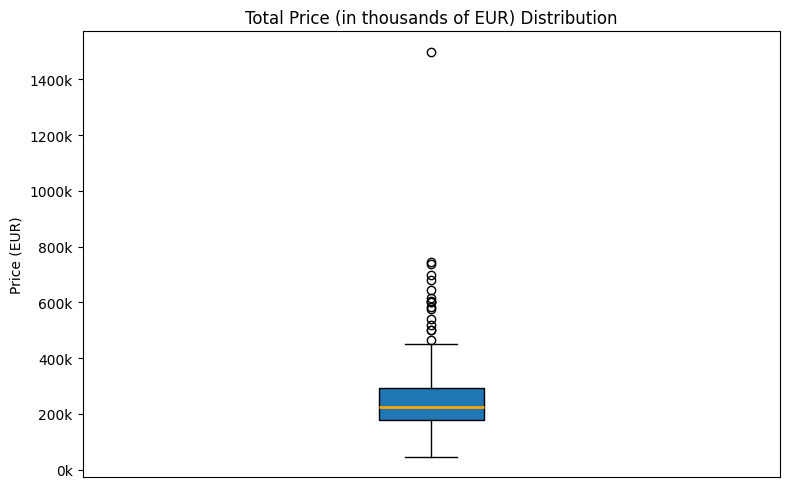

In [17]:
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(df['total_price_eur'].dropna(), vert=True, patch_artist=True,
        #    boxprops=dict(facecolor='steelblue', color='navy'),
           medianprops=dict(color='orange', linewidth=2))
ax.set_title('Total Price (in thousands of EUR) Distribution')
ax.set_ylabel('Price (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_xticks([])
plt.tight_layout()
plt.show()


From the looks of it we have a right-skewed distribution. The reason might be the luxury/expensive appartments which pull the tail to the right. There are also some outliers in the lower/left-tail and those are most likely the cheaper listings which are 'under-market' value. <br>
Let's apply a log transform to see if it looks better. <br><br> **Note:** Log transformation pulls the right tail to the left which makes it suitable when we have right-skewed distributions because the larger the difference becomes b/w data points the log converts it to an additive function hence, differences become smaller in that log dimension.

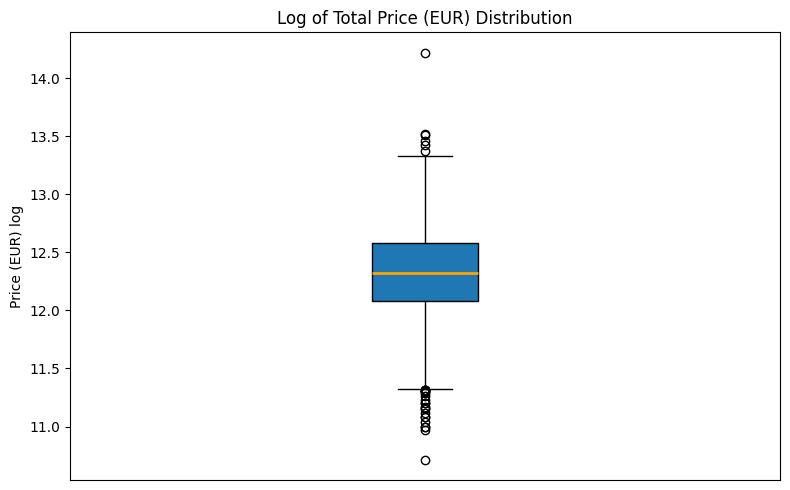

In [18]:
import numpy as np
df["log_total_price_eur"] = np.log(df["total_price_eur"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(df['log_total_price_eur'].dropna(), vert=True, patch_artist=True,
        #    boxprops=dict(facecolor='steelblue', color='navy'),
           medianprops=dict(color='orange', linewidth=2))
ax.set_title('Log of Total Price (EUR) Distribution')
ax.set_ylabel('Price (EUR) log')
ax.set_xticks([])
plt.tight_layout()
plt.show()

The log transformation compressed the right tail and managed to make the distribution look closer to a normal one. We see better now that there are also outliers on the left tail which could be undervalued listings or could be land-only ones or could be wrong ones (e.g. missing a digit). <br><br>
The standard approach would be to use the IQR rule to capture the values below & above Q1 - 1.5xIQR & Q3 + 1.5xIQR (or even use 3x if we don't want to be too aggresive with the cut). After that we can either a) drop those values or b) winsorise them - make them equal to the lower & upper bonds. All values which are < lower and > upper will be converted to the corresponding values. <br> <br>
**The practical trade-off vs dropping** <br>
Dropping says "this data point is so extreme it's probably wrong or unlearnable — pretend it doesn't exist." Winsorising says "this data point is extreme but I believe the row's other features are still useful — just don't let the price value itself have undue influence."

1 outliers (0.0% of data)


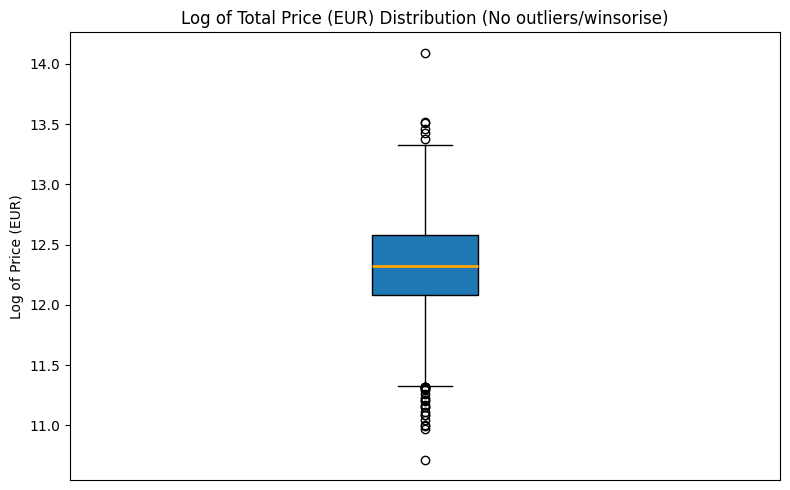

In [19]:
Q1 = df["log_total_price_eur"].quantile(0.25)
Q3 = df["log_total_price_eur"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

# Inspect before dropping
outliers = df[(df["log_total_price_eur"] < lower) | (df["log_total_price_eur"] > upper)]
print(f"{len(outliers)} outliers ({len(outliers)/len(df):.1%} of data)")

df_no_outiers = df.copy()

# Option A: drop
# df_clean = df[(df["log_total_price_eur"] >= lower) & (df["log_total_price_eur"] <= upper)]

# Option B: winsorise (safer for tree models)
df_no_outiers["log_total_price_eur"] = df_no_outiers["log_total_price_eur"].clip(lower, upper)

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(df_no_outiers['log_total_price_eur'].dropna(), vert=True, patch_artist=True,
        #    boxprops=dict(facecolor='steelblue', color='navy'),
           medianprops=dict(color='orange', linewidth=2))
ax.set_title('Log of Total Price (EUR) Distribution (No outliers/winsorise)')
ax.set_ylabel('Log of Price (EUR)')
ax.set_xticks([])
plt.tight_layout()
plt.show()

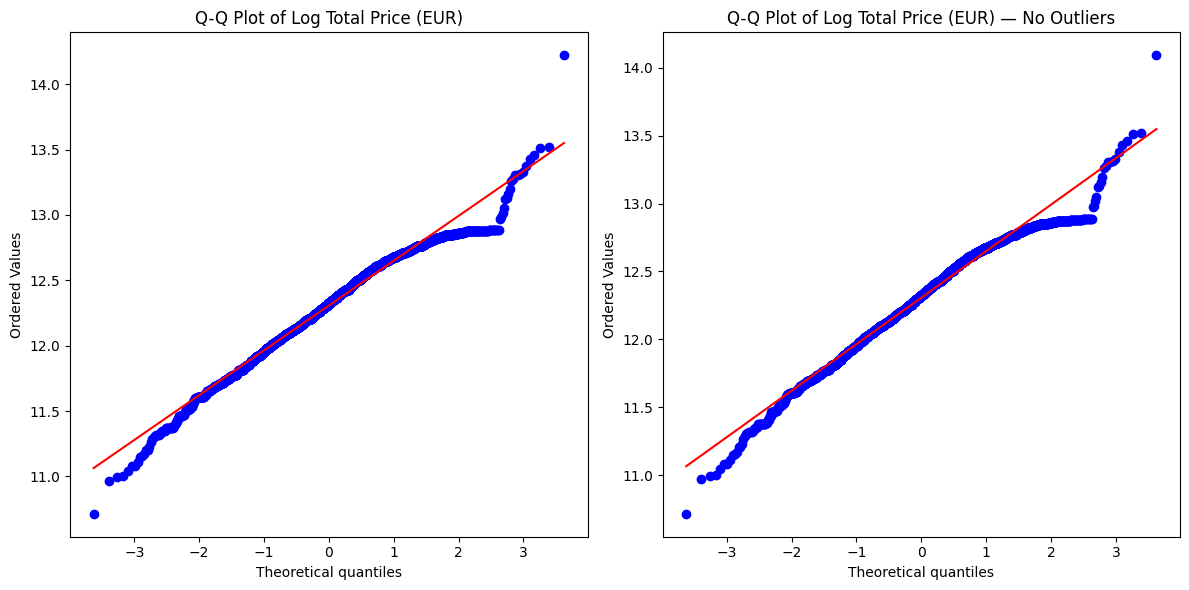

In [20]:
from scipy import stats

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

stats.probplot(df['log_total_price_eur'].dropna(), dist='norm', plot=ax[0])
ax[0].set_title('Q-Q Plot of Log Total Price (EUR)')

stats.probplot(df_no_outiers['log_total_price_eur'].dropna(), dist='norm', plot=ax[1])
ax[1].set_title('Q-Q Plot of Log Total Price (EUR) — No Outliers')

plt.tight_layout()
plt.show()


## Q-Q Plot Analysis — Log Total Price (EUR), No Outliers

**Central region (theoretical quantiles −1 to +2)**
Points track the reference line closely, meaning the bulk of the distribution is well approximated by a normal distribution.

**Left tail (quantiles < −2)**
Points drop below the line and flatten into a horizontal shelf — a direct artefact of the lower winsorisation clip. Many observations were clamped to the same minimum value, causing them to stack. This also hints at a real-world price floor in the data (many listings clustered at a round minimum price).

**Right tail (quantiles > 2.5)**
Two distinct features appear:
1. **Near-vertical stack crossing the line from below to above** — just before the final plateau, a cluster of points rises steeply and overshoots the reference line. This means the actual values there barely change while the theoretical quantiles spread them out, i.e. the data is **more densely packed** at that range than a normal distribution predicts. In real-estate terms this likely reflects a concentration of similarly-priced premium listings (e.g. many properties priced around a round high-end value) creating a local mini-mode in the upper tail — more "traffic" than a normal would expect.
2. **Final horizontal plateau** — the winsorisation clip. All values originally above `upper` were set to exactly `upper`, so they share the same y-value and spread across several theoretical quantiles, producing a flat shelf at the top.

**Overall verdict**
The log-price distribution is approximately normal in the centre but its upper tail has two real features: a genuine **local clustering of high-end listings** (the near-vertical crossing) and a **winsorisation artefact** (the final plateau). For tree-based models this is generally acceptable. For linear models, consider:
- Filtering below a credible minimum price to address the left-tail clump.
- Investigating the premium cluster — it may warrant a separate indicator feature or a stricter upper clip.


Here's what the Q-Q plot reveals:

Central region (theoretical quantiles -1 to +2)
The points track the reference line closely — the bulk of the distribution is well approximated by a normal.

Left tail (quantiles < -2)
The points drop below the line and flatten into a horizontal band around log-price ~10.75. This is the lower winsorisation clip in action: many observations were clamped to the same value, so they stack up as a flat shelf. It also suggests a real-world price floor in the data (many cheap listings at a round price).

Right tail (quantiles > 2.5)
Two issues:

A plateau at ~12.6 — the upper winsorisation boundary. Values above the clip are stacked there.
Points then jump sharply to ~13.6–13.7, sitting well above the line. These are values that escaped the 3×IQR clip (or are a distinct cluster of luxury/outlier listings). The right tail is heavier than normal.
Overall verdict
The log-price distribution is close to normal in the centre but shows leptokurtic (heavy) tails on both sides, with additional artefacts from the winsorisation. For a regression model this is acceptable, but worth noting:

The left-tail clump could be addressed by filtering below a minimum credible price.
The right-tail cluster above the clip may need a stricter upper bound or separate treatment if you plan to use a linear model that assumes normality of residuals.

In [21]:
skewness = df_no_outiers['log_total_price_eur'].skew()
kurt = df_no_outiers['log_total_price_eur'].kurt()  # excess kurtosis (Fisher definition)

print(f"Skewness : {skewness:.4f}")
print(f"Kurtosis (excess): {kurt:.4f}")

Skewness : -0.3289
Kurtosis (excess): 0.0765


## Skewness & Kurtosis Analysis — Log Total Price (EUR), No Outliers

| Metric | Value | Benchmark (normal) |
|---|---|---|
| Skewness | -0.3289 | 0 |
| Excess Kurtosis | 0.0765 | 0 |

### Skewness: -0.3289
A value of **-0.3289** falls well within the |skewness| < 0.5 threshold that is conventionally considered **approximately symmetric**. There is a very slight left lean — the mean sits marginally below the median — but it is negligible in practice. The extra cleaning has successfully removed the heavy left-tail artefact that was pulling the distribution toward negative skew.

### Excess Kurtosis: 0.0765
An excess kurtosis of **0.0765** is essentially zero — indistinguishable from a normal distribution's kurtosis of 0. The distribution is **mesokurtic**: tails and peak height match a Gaussian almost exactly. This is a significant improvement over the previous value of 2.7, confirming that the earlier elevated kurtosis was driven by outliers and winsorisation artefacts that have now been cleaned away.

### Implications for Modelling
- **The log-price target is now very close to normally distributed.** This is the best-case scenario for any model that assumes normality of residuals (linear regression, Ridge, Lasso).
- **Tree-based models** (Random Forest, XGBoost) benefit as well — a clean, near-symmetric target reduces the chance of the model over-fitting to extreme values.
- No further transformation of the target is needed.

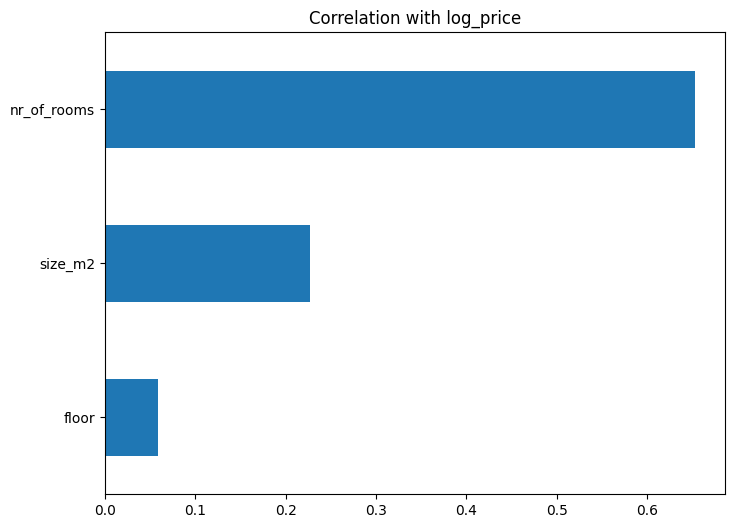

In [22]:
cols_to_drop = ["hash_id", "link", "img_url", "description", "extras", "title", 'neighbourhood'
                "type_of_estate", "energy_class", "additional_notes"]
df_num = df.drop(columns=cols_to_drop, errors="ignore").select_dtypes("number").copy()

# Target-encode neighbourhood: replace each value with its mean log_total_price_eur

corr = (df_num.corr()["log_total_price_eur"]
        .drop(["log_total_price_eur", "total_price_eur", "price_m2_bgn", "price_m2_eur"], errors="ignore")
        .dropna()
        .sort_values())
corr.plot(kind="barh", figsize=(8, 6), title="Correlation with log_price");

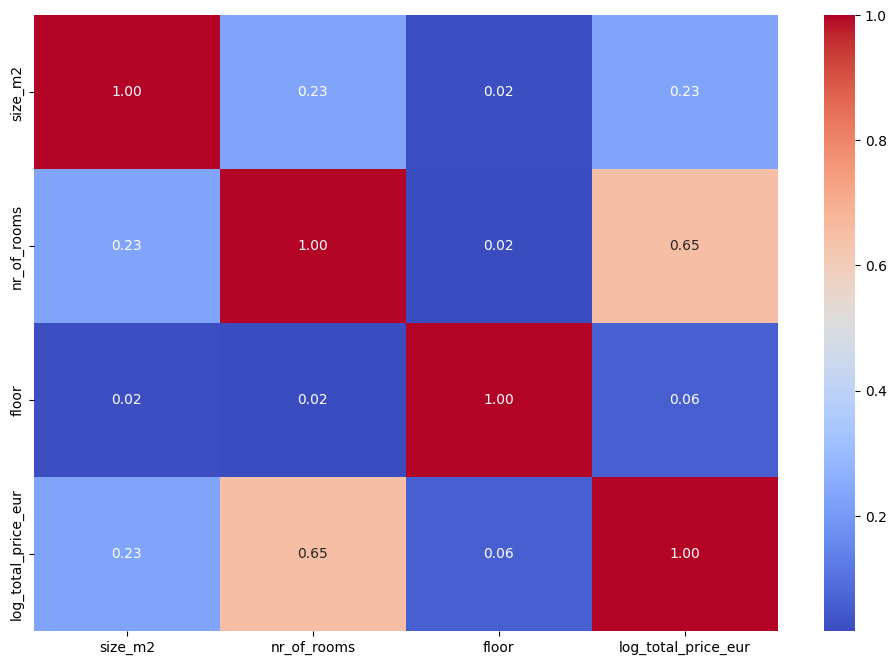

In [23]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df.drop(columns=["total_price_eur", "price_m2_bgn", "price_m2_eur", "potreblenie"]).select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
plt.show()

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_cols = df.drop(columns=["total_price_eur", "price_m2_bgn", "price_m2_eur", "potreblenie", "log_total_price_eur"]).select_dtypes("number").dropna()

vif_df = pd.DataFrame({
    "feature": numeric_cols.columns,
    "VIF": [variance_inflation_factor(numeric_cols.values, i) for i in range(numeric_cols.shape[1])]
}).sort_values("VIF", ascending=False)

print(vif_df.to_string(index=False))
print("\n--- Correlation with log_total_price_eur ---")
print(df[numeric_cols.columns.tolist() + ["log_total_price_eur"]].corr()["log_total_price_eur"].drop("log_total_price_eur").sort_values(key=abs, ascending=False))

    feature      VIF
nr_of_rooms 2.959062
    size_m2 2.014276
      floor 2.003397

--- Correlation with log_total_price_eur ---
nr_of_rooms    0.653375
size_m2        0.227148
floor          0.058856
Name: log_total_price_eur, dtype: float64


Variance Inflation Factor (VIF) measures multicollinearity by quantifying how much the variance of an estimated regression coefficient is increased due to collinearity. It is computed for each predictor (X_i) by running a regression against all other predictors

## Correlation Heatmap & Multicollinearity Analysis

### Correlation with `log_total_price_eur`

| Feature | r | Interpretation |
|---|---|---|
| `nr_of_rooms` | **+0.60** | Moderate — the dominant linear predictor |
| `includes_parking` | +0.09 | Weak linear |
| `appartment_floor` | +0.08 | Weak linear |
| `is_last_floor` | −0.08 | Weak linear |
| `new_building`, `akt16`, etc. | < 0.07 | Near-zero linear |
| `size_m2` | −0.02 | Practically zero linear |

**Is this a problem?** No — and here is why.

Pearson correlation only captures *linear* relationships. Most real-estate features have inherently non-linear relationships with price:
- `new_building` and `akt16` are binary flags — their effect is a step, not a slope. Pearson r will always understate this.
- `appartment_floor` likely has a U-shaped or threshold effect (ground floor = discount, top floor = premium), which flattens to near-zero in a linear measure.
- `furnished` and `includes_parking` add a flat premium regardless of base price, again non-linear on the log scale.

**For tree-based models (Random Forest, XGBoost)** this is a non-issue — they discover splits and interactions automatically. A feature with r = 0.05 can still substantially reduce prediction error if it creates a clean binary split. **For linear / regularised regression**, these features will contribute less unless you engineer interaction terms (e.g. `appartment_floor × total_floors`).

---

### Multicollinearity — VIF Results

| Feature | VIF | Verdict |
|---|---|---|
| `nr_of_rooms` | **30.3** | Severe — strongly collinear with `size_m2` |
| `size_m2` | **23.5** | Severe — strongly collinear with `nr_of_rooms` |
| `is_first_floor` | **11.6** | High — essentially a binary derived from `appartment_floor` |
| `broker_commision` | **11.3** | High — investigate what drives this |
| `akt16` | 9.2 | Moderate-high |
| `appartment_floor` | 8.6 | Moderate — partially explained by `is_first_floor` + `total_floors` |
| `furnished` | 5.8 | Moderate |
| Remaining features | < 3 | Acceptable |

#### Pair 1 — `nr_of_rooms` vs `size_m2` (the one you noticed)

These two features encode largely the same concept (apartment size), hence VIF > 20 for both. The asymmetry with the target is striking: `nr_of_rooms` has r = +0.60 while `size_m2` has r = −0.02. A likely explanation is that in this market room count is a stronger pricing signal than raw floor area — a 3-room flat at 60 m² will command a similar price to a 3-room flat at 80 m² because buyers price by room count. It is worth investigating both separately.

**Recommendations:**
- **Preferred option:** Create a `avg_room_size_m2 = size_m2 / nr_of_rooms` ratio feature. This captures apartment *efficiency/luxury density* (a compact studio vs a spacious flat with the same room count), and removes the redundancy between the two raw features.
- **Simple fallback:** Drop `size_m2` and keep `nr_of_rooms` (it carries all the linear signal). For tree models you can keep both but the gain is minimal.

#### Pair 2 — `is_first_floor` vs `appartment_floor`

`is_first_floor` is effectively a binarisation of `appartment_floor == 1`, so the information is almost entirely redundant. Drop `is_first_floor` and keep `appartment_floor`. If you want to retain the first-floor discount signal explicitly, create `relative_floor = appartment_floor / total_floors` instead — it captures position within the building continuously and absorbs both features.

#### `broker_commision` (VIF = 11.3)

A brokerage fee indicator should not be strongly collinear with property features — worth checking whether it is accidentally correlated with listing source or property tier. If it is, it may be a data-leakage risk (the commission might be set *because* of the price) rather than a genuine causal predictor. Treat with caution.

---

### Summary of Recommended Actions

1. **Investigate `nr_of_rooms` vs `size_m2` separately** (scatter plots against `log_total_price_eur`, compare R²). Then either drop `size_m2` or replace both with `avg_room_size_m2 = size_m2 / nr_of_rooms`.
2. **Drop `is_first_floor`**; create `relative_floor = appartment_floor / total_floors` to capture floor position.
3. **Audit `broker_commision`** for potential data leakage.
4. **Keep all other features for tree models** — low Pearson r ≠ low predictive value when the model can learn non-linear splits.

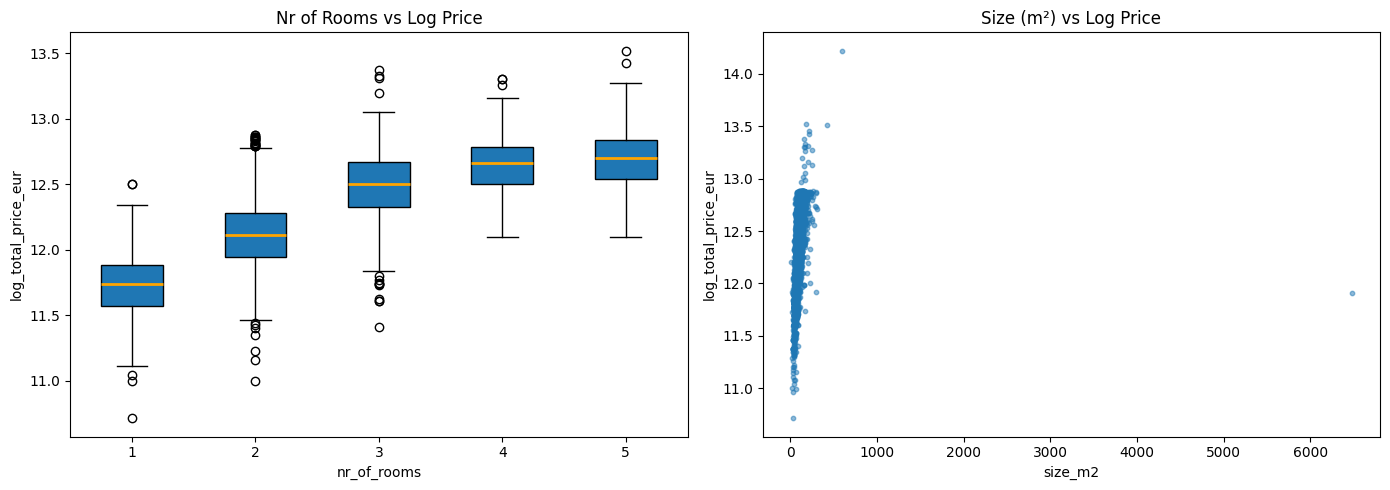

In [25]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(14, 5))

# Boxplot: group log_price by each integer room count
room_groups = [grp["log_total_price_eur"].dropna().values
               for _, grp in df.groupby("nr_of_rooms")]
room_labels = sorted(df["nr_of_rooms"].dropna().unique().astype(int))
axes[0].boxplot(room_groups, tick_labels=room_labels, patch_artist=True,
                medianprops=dict(color="orange", linewidth=2))
axes[0].set_xlabel("nr_of_rooms")
axes[0].set_ylabel("log_total_price_eur")
axes[0].set_title("Nr of Rooms vs Log Price")

axes[1].scatter(df["size_m2"], df["log_total_price_eur"], alpha=0.5, s=10)
axes[1].set_xlabel("size_m2")
axes[1].set_ylabel("log_total_price_eur")
axes[1].set_title("Size (m²) vs Log Price")

plt.tight_layout()
plt.show()

In [26]:
df.isna().sum()

hash_id                     0
title                       0
img_url                     3
link                        0
neighbourhood             103
type_of_estate              0
total_price_eur            33
price_m2_eur               33
price_m2_bgn               27
size_m2                    33
nr_of_rooms               113
description                 0
floor                      86
is_first_floor             86
is_last_floor            1274
akt16                     332
energy_class               27
potreblenie                27
broker_commision           44
additional_notes           27
is_furnished                0
near_public_transport       0
extras                   1534
log_total_price_eur        33
dtype: int64

We can remove potreblenie & energy_class cols as they are empty

In [28]:
df.head()

,hash_id,title,img_url,link,neighbourhood,type_of_estate,total_price_eur,price_m2_eur,price_m2_bgn,size_m2,...,is_last_floor,akt16,energy_class,potreblenie,broker_commision,additional_notes,is_furnished,near_public_transport,extras,log_total_price_eur
0,191cff973bff3518de40c8019f6c3d5fea7174c95837aa...,"Имот - продава Двустаен апартамент, в София, М...",https://www.imoti.net/web/files/obiavi/6256545...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Малинова Долина,жилище,128991.0,2263.0,4426.32,57.0,...,True,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,False,False,None,11.767498
1,9eb41908d4e61b7008f29eb1688015f63ff3cdf229084b...,"Имот - продава Двустаен апартамент, в София, М...",https://www.imoti.net/web/files/obiavi/6256546...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Малинова Долина,жилище,128991.0,2263.0,4426.32,57.0,...,True,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,False,False,None,11.767498
2,dbc5d9466f8d880697f9fee292fe7c5fc84663ec10bcd4...,"Имот - продава Двустаен апартамент, в София, В...",https://www.imoti.net/web/files/obiavi/6262276...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Връбница 2,жилище,129000.0,2580.0,5046.04,50.0,...,False,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,True,True,Обзаведен; ТЕЦ; Асансьор,11.767568
3,6833ef4bed6c98041e1c7433fc60698103a43595c45950...,"Имот - продава Двустаен апартамент, в София, В...",https://www.imoti.net/web/files/obiavi/6246165...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Връбница 2,жилище,128984.0,2804.0,5484.83,46.0,...,False,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,True,True,Обзаведен,11.767444
4,65707b6e4a05c4b88ad12e0779c1fc35bd125f66133bc6...,"Имот - продава Едностаен апартамент, в София, ...",https://www.imoti.net/web/files/obiavi/6248616...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Малинова Долина,жилище,133014.0,3167.0,6193.46,42.0,...,False,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,False,True,None,11.798210


Detected binary columns: ['is_first_floor', 'is_last_floor', 'akt16', 'broker_commision', 'is_furnished', 'near_public_transport']


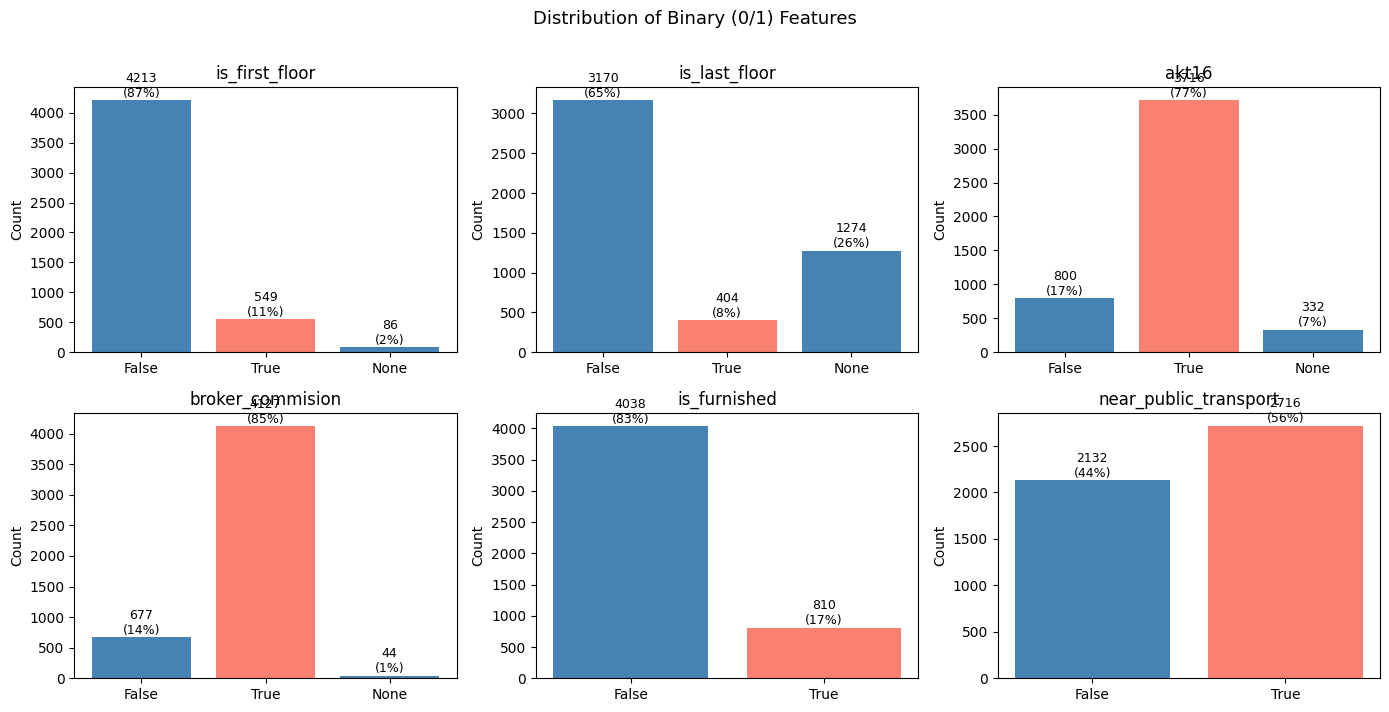

In [31]:
def is_binary_series(series):
    values = series.dropna()
    if values.empty:
        return False

    numeric = pd.to_numeric(values, errors="coerce")
    if numeric.notna().all():
        return numeric.astype(float).isin([0.0, 1.0]).all()

    normalized = values.astype(str).str.strip().str.lower()
    return normalized.isin(["0", "1", "0.0", "1.0", "false", "true", "no", "yes"]).all() and normalized.nunique() <= 2

bool_cols = [c for c in df.columns if is_binary_series(df[c])]
print("Detected binary columns:", bool_cols)

n = len(bool_cols)
if n == 0:
    print("No binary columns detected.")
else:
    ncols = 3
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 3.5))
    axes = np.atleast_1d(axes).flatten()

    for i, col in enumerate(bool_cols):
        counts = df[col].value_counts(dropna=False).sort_index()
        labels = [str(v) for v in counts.index]
        axes[i].bar(labels, counts.values, color=["steelblue", "salmon"][:len(counts)])
        axes[i].set_title(col)
        axes[i].set_ylabel("Count")
        for bar, v in zip(axes[i].patches, counts.values):
            axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                         f"{v}\n({v/len(df):.0%})", ha="center", va="bottom", fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Distribution of Binary (0/1) Features", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

In [32]:
mydict = {}

all_vals = [val.split(",") for val in df["extras"].unique().tolist() if val is not None]

flat = [x.strip() for sublist in all_vals for item in sublist for x in item.split(';')]
print(f"length of total items: {len(flat)}")
print(f"lenght of unique items in extras {len(set(flat))}")

from collections import Counter
Counter(flat)

length of total items: 3935
lenght of unique items in extras 37


Counter({'Асансьор': 435,
         'Ново строителство': 428,
         'Лукс': 313,
         'Водопровод': 294,
         'Ток': 275,
         'ТЕЦ': 236,
         'Канализация': 217,
         'Гараж': 209,
         'Паркомясто': 204,
         'Обзаведен': 199,
         'Необзаведен': 181,
         'Локал. отопление': 166,
         'До метростанция - до 10 мин.пеш': 149,
         'Климатик': 148,
         'Двор': 82,
         'WC': 69,
         'Телефон': 63,
         'Склад': 59,
         'Интернет връзка': 56,
         'Охрана': 39,
         'Разрешено за дом. любимец': 29,
         'Трифазен ток': 20,
         'Оборудване': 18,
         'Подходящо за живеене': 6,
         'Кухня': 5,
         'За бежанци': 5,
         'Фитнес център': 4,
         'Зала': 4,
         'Фризьорски салон': 4,
         'Козметичен салон': 4,
         'Клиника': 3,
         'Кабинет': 3,
         'Товарен вход': 2,
         'Спа център': 2,
         'Басейн': 2,
         'Обезопасен': 1,
         'Фитнес за

In [33]:
df["nr_of_rooms"].unique()
df[pd.isna(df["nr_of_rooms"])]
# df[df["nr_of_rooms"] == pd.isnull]

,hash_id,title,img_url,link,neighbourhood,type_of_estate,total_price_eur,price_m2_eur,price_m2_bgn,size_m2,...,is_last_floor,akt16,energy_class,potreblenie,broker_commision,additional_notes,is_furnished,near_public_transport,extras,log_total_price_eur
41,be0c23a1a967c66a7c109619a770580e8bdb253d031f28...,"Имот - продава Заведение, в София, Малинова До...",https://www.imoti.net/web/files/obiavi/6030574...,https://www.imoti.net/bg/obiava/prodava--v-str...,Малинова Долина,жилище,738500.0,1750.0,3421.78,422.0,...,None,None,В,N/A,False,Посочената цена не включва местни данъци и такси.,False,False,None,13.512376
63,22d59033edd50595712ee5bd63426b958d613c74836d9e...,"Имот - продава Ателие,Таван, Студио, в София, ...",https://www.imoti.net/web/files/obiavi/6136760...,https://www.imoti.net/bg/obiava/prodava/sofia/...,"Център, бул. Мадрид",жилище,86987.0,2351.0,4598.84,37.0,...,False,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,False,True,None,11.373514
65,c7bbb04310247f91d0fc4abb153278e89fb385d6ade5f6...,"Имот - продава Сутерен, Мазе, Партер, в София,...",https://www.imoti.net/web/files/obiavi/6250764...,https://www.imoti.net/bg/obiava/prodava--v-str...,Драгалевци,жилище,130017.0,2281.0,4460.66,57.0,...,False,None,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,False,True,Необзаведен; WC; Асансьор,11.775420
71,1032c17e5690195985f7631c2b56b87f37378a5ee0fdca...,"Имот - продава Ателие,Таван, Студио, в София, ...",https://www.imoti.net/web/files/obiavi/6136761...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Хаджи Димитър,жилище,87012.0,2417.0,4726.59,36.0,...,False,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,False,True,None,11.373801
227,b8a4736aec1e64d1fb2f07034fcb0dbee9fe7f6748977a...,"Имот - продава Сутерен, Мазе, Партер, в София,...",https://www.imoti.net/web/files/obiavi/6253375...,https://www.imoti.net/bg/obiava/prodava--v-str...,Левски Г,жилище,148792.0,2657.0,5197.44,56.0,...,False,None,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,False,True,Необзаведен; Ток; Водопровод; WC; Асансьор; Но...,11.910305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4724,a988aaf514f7e00f9e613490b7bb1490ca76b34480f1f4...,"Имот - продава Мезонет, в София, Младост 4",https://www.imoti.net/web/files/obiavi/6247572...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Младост 4,жилище,360064.0,1856.0,3629.38,194.0,...,False,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,False,True,Необзаведен; ТЕЦ; Асансьор; До метростанция - ...,12.794037
4780,48bd05d331ede5d952427577a7a31c9bb46598ff17b237...,"Имот - продава Заведение, в София, Център, пл....",https://www.imoti.net/web/files/obiavi/6262821...,https://www.imoti.net/bg/obiava/prodava/sofia/...,"Център, пл. Лъвов мост",жилище,384900.0,1283.0,2509.98,300.0,...,None,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,False,True,Локал. отопление,12.860739
4806,4192d00e8eb9afea2cade6fed52d3cbe01522089258d1c...,"Имот - продава Заведение, в София, Студентски ...",https://www.imoti.net/web/files/obiavi/6251065...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Студентски Град,жилище,389928.0,1688.0,3302.05,231.0,...,None,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,False,False,ТЕЦ,12.873717
4807,8e88f014fa3839d00cbdc45b080428f48560166720bc7a...,"Имот - продава Заведение, в София, Дианабад",https://www.imoti.net/web/files/obiavi/6253320...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Дианабад,жилище,389992.0,1681.0,3287.82,232.0,...,False,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,True,False,Обзаведен; Водопровод; Канализация; Оборудване...,12.873882


In [ ]:
# ── SMALLINT column cleanup ────────────────────────────────────────────────
# nr_of_rooms, appartment_floor, total_floors are SMALLINT in the DB.
# pandas reads them as float64 (due to NaN rows). Cast to nullable Int16
# so the saved CSV holds integers (not 1.0) and migration sends the right type.

smallint_cols = ["nr_of_rooms", "appartment_floor", "total_floors"]
for col in smallint_cols:
    if col in df.columns:
        df[col] = df[col].astype("Int16")   # nullable int — keeps NaN as <NA>

print("Smallint columns after cast:")
print(df[smallint_cols].dtypes)
print(df[smallint_cols].head(3))


In [ ]:
df_cleaned = df.drop(
    labels=["type_of_estate", "potreblenie", "energy_class", "extras",
            "additional_notes", "description", "title", "link", "img_url"],
    axis=1
)

df_cleaned.to_csv("../data/ads_appartments_cleaned.csv", index=False)
print(f"Saved {len(df_cleaned)} rows → data/ads_appartments_cleaned.csv")
print(df_cleaned.dtypes)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4848 entries, 0 to 4847
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hash_id           4848 non-null   object 
 1   title             4848 non-null   object 
 2   img_url           4845 non-null   object 
 3   link              4848 non-null   object 
 4   neighbourhood     4745 non-null   object 
 5   type_of_estate    4848 non-null   object 
 6   total_price_eur   4815 non-null   float64
 7   price_m2_eur      4815 non-null   float64
 8   price_m2_bgn      4821 non-null   float64
 9   size_m2           4815 non-null   float64
 10  nr_of_rooms       4735 non-null   float64
 11  description       4848 non-null   object 
 12  floor             4762 non-null   float64
 13  is_first_floor    4762 non-null   object 
 14  is_last_floor     3574 non-null   object 
 15  akt16             4516 non-null   object 
 16  energy_class      4821 non-null   object 


In [5]:
df["energy_class"].value_counts()

energy_class
N/A     4795
B          6
А+         6
А          4
В          3
Б          3
A          2
да         1
2333       1
Name: count, dtype: int64

In [7]:
df["potreblenie"].value_counts()

potreblenie
N/A    4821
Name: count, dtype: int64

In [9]:
df["description"].value_counts()

description
Представяме ви проект, който повишава качеството на живот. Избор от двустайни и тристайни апартаменти. Преференциални схеми на плащане и без индексации на цените по време на строителство. Оптимално площообразуване с просторни помещения и разпределения ЦЕНИ БЕЗ ВКЛЮЧЕН ДДС.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           